In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

## Load Data:

In [2]:
df = pd.read_csv("spam.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.Category.value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

There is class imbalance but let's just first try the model if accuracy is less we will resolve this imbalance.

## Train-Test Split:

In [11]:
# Create train-test split
X = df["Message"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
X_train.head()

1658    S:-)if we have one good partnership going we w...
1509    Sounds like something that someone testing me ...
3266    44 7732584351, Do you want a New Nokia 3510i c...
5199           Ugh my leg hurts. Musta overdid it on mon.
3217    URGENT! We are trying to contact U. Todays dra...
Name: Message, dtype: object

Model doesn't understands text so we need to convert this Message text to numbers, but here we can't use OneHotEncoding coz it works only on single categorires not the complete sentences.

So We will sklearn method called CountVectorizer(). Which will convert the text into numbers by creting matrix of all unique words present in the whole data and if that word is present in the sentence value will be 1 otherwise 0.

## Encoding:

In [16]:
# Encoding:
v = CountVectorizer()
X_train_count = v.fit_transform(X_train)
X_test_count = v.transform(X_test)

len(X_train_count.toarray()[1])

7705

So the total numbers of unique words are 7705 in this data and so there are 7705 total columns in it.

## Model Training:

In [17]:
model = MultinomialNB()
model.fit(X_train_count, y_train)

y_pred = model.predict(X_test_count)

## Model Evaluation : Accuracy, Precision, Recall:

In [18]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



## Model Evaluation : Confusion Matrix:

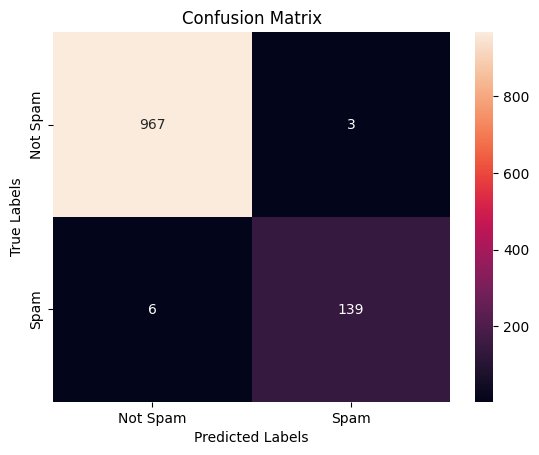

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Not Spam","Spam"], yticklabels=["Not Spam","Spam"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [27]:
# Let's check this model with our own sms example

sms = [
'Free entry in a weekly contest. Text WIN to 80085 now.',
'Can you send me the notes from today’s class?']

In [28]:
# First Encode these sms
sms_count = v.transform(sms)
sms_count

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 17 stored elements and shape (2, 7705)>

In [29]:
model.predict(sms_count)

array(['spam', 'ham'], dtype='<U4')

## Using Sklearn Pipeline:

In [31]:
pipe = Pipeline([
    ('count_vectorizer', CountVectorizer()),
    ('nb_classifier', MultinomialNB())
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

